# 실습 1 신용카드 이상 탐지

데이터 준비
실습에 사용될 데이터는 Kaggle의 Credit Card Fraud Detection 데이터셋입니다. 이 데이터셋은 거래의 시간, 금액과 함께 28개의 PCA 변환된 특성들을 포함하고 있습니다. 'Class' 레이블은 사기 거래를 나타내는 1과 정상 거래를 나타내는 0으로 구분됩니다.

데이터를 불러오고, 전처리하는 기본적인 코드는 아래와 같습니다:

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 데이터를 불러옵니다.
# 불러오기 안될때: 해당 파일이 어디에 있는지 회귀, 분석 or 트리, 비지도학습 or 머신러닝실습자료 확인하기
data = pd.read_csv('./회귀, 분류/creditcard.csv',encoding='cp949')
data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [2]:
# target 데이터(class)의 분포를 확인합니다.
print("Class Distribution:")
print(data['Class'].value_counts())

# 'time' 대신 대문자 'Time'으로 변경하여 컬럼을 삭제합니다.
X = data.drop(['Time', 'Class'], axis=1)
y = data['Class']

# 분리가 잘 되었는지 상위 5행 데이터 확인
X.head()

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [3]:
# 데이터를 훈련 세트와 테스트 세트로 분할합니다.
# 데이터 분할 예시 (이어서 실행해 보세요!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(y_train.value_counts())
print(X_train.value_counts())

# 데이터 표준화 작업을 실시합니다,
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Class
0    199020
1       344
Name: count, dtype: int64
V1         V2         V3         V4         V5         V6         V7         V8         V9         V10        V11        V12        V13        V14        V15        V16        V17        V18        V19        V20        V21        V22        V23        V24        V25        V26        V27        V28        Amount
 2.055797  -0.326668  -2.752041  -0.842316   2.463072   3.173856  -0.432126   0.727706   0.608606  -0.075186   0.063504   0.350564  -0.141238   0.690972   1.275257  -0.371962  -0.601957  -0.052640  -0.330590  -0.180370   0.269765   0.844627   0.020675   0.726212   0.366624  -0.398828   0.027735  -0.060282  1.00      55
 1.302378  -0.606529  -0.681986  -1.904603   1.326623   3.436312  -1.145127   0.959147   1.671302  -1.022946  -0.191423   0.631027   0.031907  -0.031425   1.446627  -0.121820  -0.651405   0.617970   0.927600   0.005757  -0.064208  -0.080587  -0.072991   1.018136   0.663575  -0.671323   0.096801   0.028697  

In [5]:
# 데이터를 훈련 세트와 테스트 세트로 분할합니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(y_train.value_counts())
print(y_test.value_counts())


# 데이터 표준화 작업을 실시합니다,
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



Class
0    227451
1       394
Name: count, dtype: int64
Class
0    56864
1       98
Name: count, dtype: int64


In [ ]:
# 데이터 줄이기
# (데이터 줄이거나 늘리기 가능)
# 시험:  Feature_importance를 가지고 줄이고 최대
# Feature_importance



#상관관계를 구해서, 상관관계가 높은 항목들을 병합

In [ ]:
# 1. 모델 학습 (반드시 fit을 먼저 해야 중요도가 계산됩니다)(냬꺼)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 2. 중요도 추출 및 데이터프레임 만들기
import pandas as pd
import numpy as np

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

# 3. 중요도 높은 순으로 정렬
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df.head(10)) # 상위 10개 출력

In [10]:
# 로지스틱 회귀 모델을 생성하고 학습합니다.(다른 사람)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, accuracy_score
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# 학습된 모델로 테스트 데이터를 예측하고 평가합니다.
예측값 = lr.predict(X_test)

# 정확도, 정밀도, F1 Score를 계산 및 출력합니다.
print("Accuracy:", accuracy_score(y_test, 예측값))
print("Precision:", precision_score(y_test, 예측값, zero_division=0))
print("F1 Score:", f1_score(y_test, 예측값, zero_division=0))

# AUC 점수를 계산합니다.
lr_auc_score = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
print("Logistic Regression AUC score:", lr_auc_score)

Accuracy: 0.9991046662687406
Precision: 0.8615384615384616
F1 Score: 0.6871165644171779
Logistic Regression AUC score: 0.9768823645102385


## Decision Tree 로 직접해보기

In [ ]:
# 결정 트리 모델을 생성하고 학습합니다.

# 학습된 모델로 테스트 데이터를 예측하고 평가합니다.

# AUC 점수를 계산합니다.


In [12]:
# 결정 트리 모델을 생성하고 학습합니다.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, precision_score, accuracy_score, roc_auc_score
dt = DecisionTreeClassifier()


# 학습된 모델로 테스트 데이터를 예측하고 평가합니다.
dt.fit(X_train, y_train)
예측값 = dt.predict(X_test)

# 정확도, 정밀도, F1 Score를 계산 및 출력합니다.
print("Accuracy:", accuracy_score(y_test, 예측값))
print("Precision:", precision_score(y_test, 예측값, zero_division=0))
print("F1 Score:", f1_score(y_test, 예측값, zero_division=0))

# AUC 점수를 계산합니다.
dt_auc_score = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])
print("Decision Tree AUC score:", dt_auc_score)

Accuracy: 0.9990871107053826
Precision: 0.7090909090909091
F1 Score: 0.75
Decision Tree AUC score: 0.8976778105727378


## Random Forest 로 해보기

In [ ]:
# 랜덤 포레스트 모델을 생성하고 학습합니다.


# 학습된 모델로 테스트 데이터를 예측하고 평가합니다.

# AUC 점수를 계산합니다.


Accuracy: 0.9995611109160493
Precision: 0.974025974025974
F1 Score: 0.8571428571428571
Random Forest AUC Score: 0.9526103456295292
Feature Importances: [0.01627813 0.01253408 0.01458116 0.03450583 0.01359336 0.01695684
 0.03051118 0.01284636 0.03792694 0.08218315 0.08582745 0.11929237
 0.00937955 0.11481604 0.01225088 0.08075189 0.14736601 0.02523745
 0.01262306 0.01405877 0.01387184 0.01056663 0.00875691 0.0111819
 0.00920813 0.01772546 0.01292567 0.01026412 0.01197886]


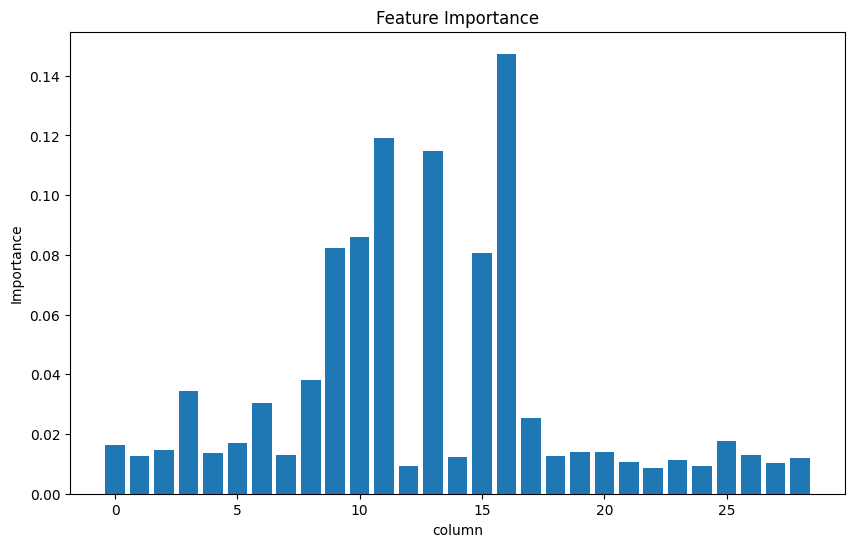

Most Important Feature Index: 16
Most Important Feature Name: V17
Top 10 Feature Indices: [16 11 13 10  9 15  8  3  6 17]
Top 10 Feature Names: Index(['V17', 'V12', 'V14', 'V11', 'V10', 'V16', 'V9', 'V4', 'V7', 'V18'], dtype='str')
Accuracy: 0.9995962220427653
Precision: 0.987012987012987
F1 Score: 0.8685714285714285
Random Forest (Top 10 Features) AUC Score: 0.947902550159062


In [14]:
# 랜덤 포레스트 실습: 기본 모델 성능 확인 -> 중요 변수 추출 -> 상위 변수만으로 재학습
from sklearn.ensemble import RandomForestClassifier

# n_estimators: 트리 개수, n_jobs=-1: CPU 코어 전체 사용(학습 속도 개선)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 1) 전체 변수로 학습/예측
rf.fit(X_train, y_train)
예측값 = rf.predict(X_test)

# 2) 분류 평가지표 출력 (불균형 데이터이므로 Accuracy만 보지 말고 Precision/F1도 함께 확인)
print("Accuracy:", accuracy_score(y_test, 예측값))
print("Precision:", precision_score(y_test, 예측값, zero_division=0))
print("F1 Score:", f1_score(y_test, 예측값, zero_division=0))

# 3) AUC 계산: predict_proba의 양성(1) 확률을 사용
rf_auc_score = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print("Random Forest AUC Score:", rf_auc_score)

# 4) Feature Importance 확인 (모델이 어떤 변수를 중요하게 보는지 해석)
import matplotlib.pyplot as plt
import numpy as np
imp = rf.feature_importances_
print("Feature Importances:", imp)

# 중요도 막대그래프
plt.figure(figsize=(10, 6))
plt.bar(range(len(imp)), imp)
plt.xlabel('column')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()

# 가장 중요한 변수 1개 확인
most_important_feature = np.argmax(imp)
print("Most Important Feature Index:", most_important_feature)
print("Most Important Feature Name:", X.columns[most_important_feature])

# 중요도 기준 상위 10개 변수 인덱스 추출 (내림차순)
top_10_features = np.argsort(imp)[-10:][::-1]
print("Top 10 Feature Indices:", top_10_features)
print("Top 10 Feature Names:", X.columns[top_10_features])

# 5) 상위 10개 변수만으로 다시 학습/평가하여 성능 비교
x_top_10 = X.iloc[:, top_10_features]
x_train_top_10, x_test_top_10, y_train, y_test = train_test_split(x_top_10, y, test_size=0.2, random_state=42)
x_train_top_10 = scaler.fit_transform(x_train_top_10)
x_test_top_10 = scaler.transform(x_test_top_10)

rf_top_10 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_top_10.fit(x_train_top_10, y_train)
예측값_top_10 = rf_top_10.predict(x_test_top_10)

print("Accuracy:", accuracy_score(y_test, 예측값_top_10))
print("Precision:", precision_score(y_test, 예측값_top_10, zero_division=0))
print("F1 Score:", f1_score(y_test, 예측값_top_10, zero_division=0))

rf_top_10_auc_score = roc_auc_score(y_test, rf_top_10.predict_proba(x_test_top_10)[:, 1])
print("Random Forest (Top 10 Features) AUC Score:", rf_top_10_auc_score)

## 퀴즈) SVM 사용해보기

In [15]:
# SVM 실습(대용량용): LinearSVC 사용
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score
import time

# 실행 시간 측정 (시험에서 속도 비교 질문 대비)
start = time.time()

# 핵심 포인트: 대용량 데이터에서는 기본 SVC(RBF)보다 LinearSVC가 훨씬 빠름
svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=5000)

# 학습/예측
svm.fit(X_train, y_train)
예측값 = svm.predict(X_test)

# 분류 지표 출력
print("Accuracy:", accuracy_score(y_test, 예측값))
print("Precision:", precision_score(y_test, 예측값, zero_division=0))
print("F1 Score:", f1_score(y_test, 예측값, zero_division=0))

# LinearSVC는 predict_proba가 없으므로 decision_function 점수로 AUC 계산
svm_auc_score = roc_auc_score(y_test, svm.decision_function(X_test))
print("Linear SVM AUC score:", svm_auc_score)

# 전체 소요 시간 확인
print(f"학습+예측 시간: {time.time() - start:.2f}초")

Accuracy: 0.9813559917137741
Precision: 0.07793345008756568
F1 Score: 0.1435483870967742
Linear SVM AUC score: 0.981975253522906
학습+예측 시간: 2.29초


# 가장 AUC점수가 높았던 모델 GridSearch로 튜닝하기

In [17]:
# 가장 AUC가 높았던 Linear SVM 모델을 GridSearch로 튜닝
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, f1_score
import time

start = time.time()

# 불균형 데이터이므로 클래스 비율을 유지하는 StratifiedKFold 사용
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 시험 포인트: C(규제 강도), class_weight(불균형 대응), max_iter(수렴 반복수)
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    'max_iter': [3000, 5000]
}

# scoring='roc_auc'로 AUC 기준 최적 파라미터 탐색
grid = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# 하이퍼파라미터 탐색 실행
grid.fit(X_train, y_train)

# 최적 모델로 테스트셋 최종 평가
best_model = grid.best_estimator_
예측값 = best_model.predict(X_test)
auc = roc_auc_score(y_test, best_model.decision_function(X_test))

print('Best Params:', grid.best_params_)
print('Best CV AUC:', grid.best_score_)
print('Test Accuracy:', accuracy_score(y_test, 예측값))
print('Test Precision:', precision_score(y_test, 예측값, zero_division=0))
print('Test F1 Score:', f1_score(y_test, 예측값, zero_division=0))
print('Test AUC:', auc)
print(f"GridSearch 소요시간: {time.time() - start:.2f}초")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Params: {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 3000}
Best CV AUC: 0.9756560185742466
Test Accuracy: 0.9813735472771321
Test Precision: 0.07800175284837861
Test F1 Score: 0.14366424535916061
Test AUC: 0.9820158085744146
GridSearch 소요시간: 9.01초
